# Support Vector Machines 

Welcome to your SVM assignment! Just follow along with the notebook and instructions below. We will be analyzing the famous iris data set!

## The Data
For this series of lectures, we will be using the famous [Iris flower data set](http://en.wikipedia.org/wiki/Iris_flower_data_set). 

The Iris flower data set or Fisher's Iris data set is a multivariate data set introduced by Sir Ronald Fisher in the 1936 as an example of discriminant analysis. 

The data set consists of 50 samples from each of three species of Iris (Iris setosa, Iris virginica and Iris versicolor), so 150 total samples. Four features were measured from each sample: the length and the width of the sepals and petals, in centimeters.

Here's a picture of the three different Iris types:

In [7]:
# # The Iris Setosa
from IPython.display import Image, display
url = 'http://upload.wikimedia.org/wikipedia/commons/5/56/Kosaciec_szczecinkowaty_Iris_setosa.jpg'
display(Image(url=url, width=300, height=300))

In [8]:
# The Iris Versicolor
url = 'http://upload.wikimedia.org/wikipedia/commons/4/41/Iris_versicolor_3.jpg'
display(Image(url=url, width=300, height=300))

In [9]:
# The Iris Virginica
url = 'http://upload.wikimedia.org/wikipedia/commons/9/9f/Iris_virginica.jpg'
display(Image(url=url, width=300, height=300))

The iris dataset contains measurements for 150 iris flowers from three different species.

The three classes in the Iris dataset:

    Iris-setosa (n=50)
    Iris-versicolor (n=50)
    Iris-virginica (n=50)

The four features of the Iris dataset:

    sepal length in cm
    sepal width in cm
    petal length in cm
    petal width in cm

## Get the data

**Use seaborn to get the iris data by using: iris = sns.load_dataset('iris') **

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Load iris dataset
# Note: sns.load_dataset requires internet; we use sklearn's iris
# which contains the exact same data and reconstruct it as a DataFrame.
from sklearn.datasets import load_iris
raw = load_iris()
iris = pd.DataFrame(raw.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
iris['species'] = pd.Categorical.from_codes(raw.target, ['setosa','versicolor','virginica'])
iris.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


Let's visualize the data and get you started!

## Exploratory Data Analysis

Time to put your data viz skills to the test! Try to recreate the following plots, make sure to import the libraries you'll need!

**Import some libraries you think you'll need.**

In [11]:
# Libraries already imported above.
# Quick overview of the dataset
print(iris.shape)
print(iris['species'].value_counts())
iris.describe()

(150, 5)
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


** Create a pairplot of the data set. Which flower species seems to be the most separable?**

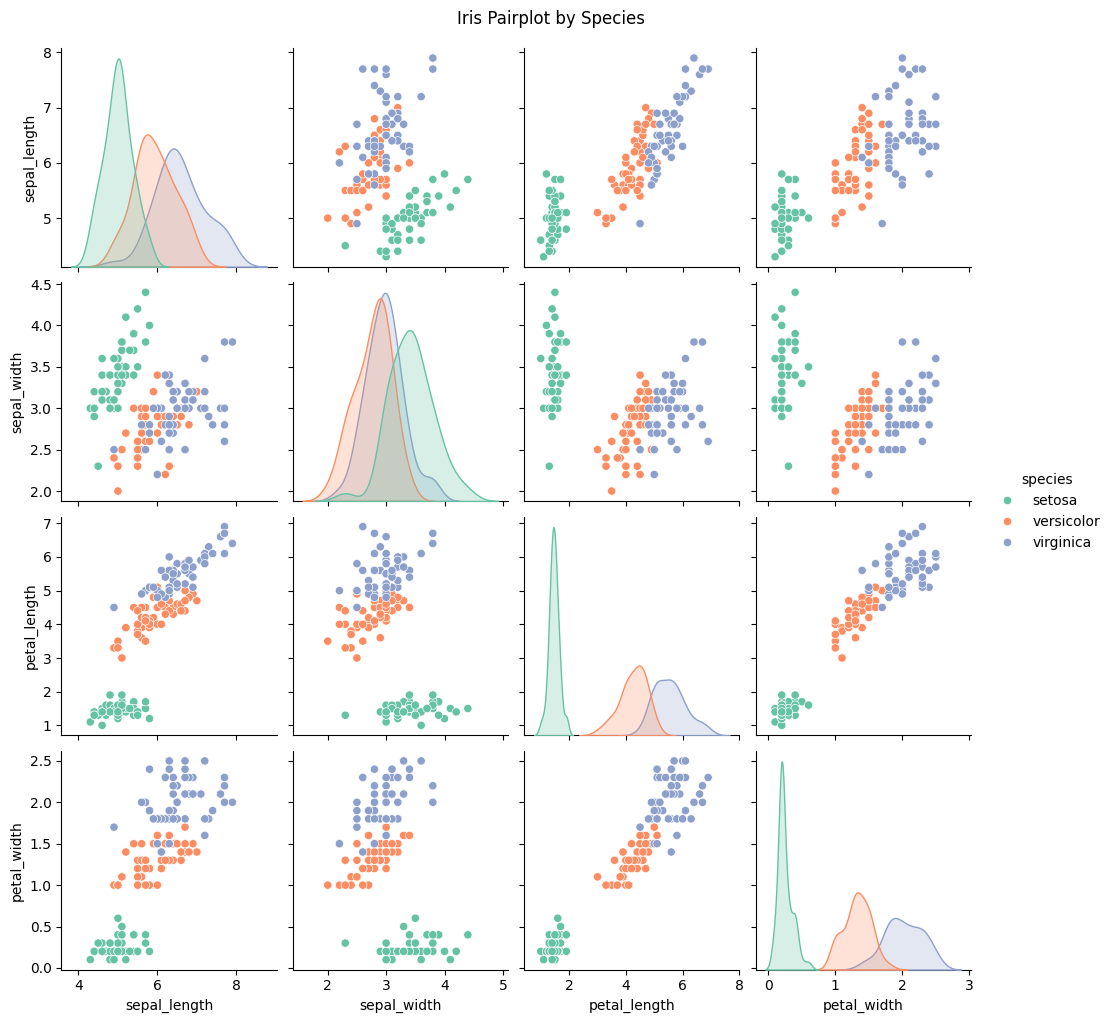

In [12]:
# Pairplot — setosa is clearly the most linearly separable species
sns.pairplot(iris, hue='species', palette='Set2')
plt.suptitle('Iris Pairplot by Species', y=1.02)
plt.show()
# Observation: Iris setosa is the most separable — its clusters are
# clearly distinct from versicolor and virginica across all feature pairs.

**Create a kde plot of sepal_length versus sepal width for setosa species of flower.**

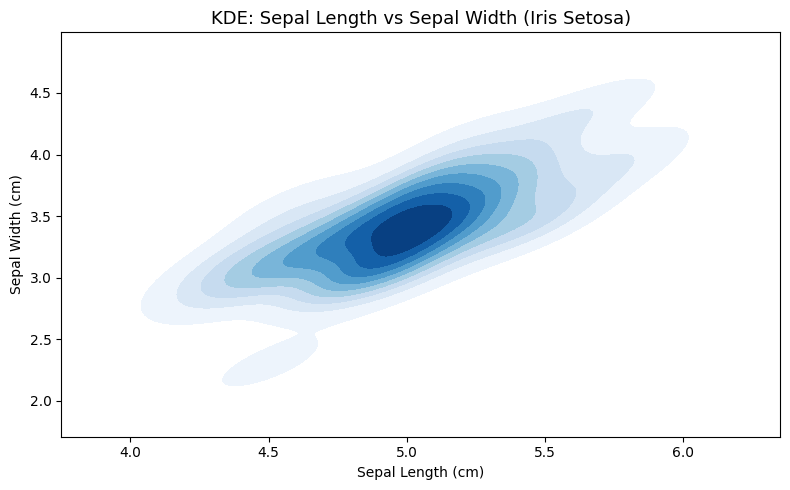

In [13]:
# KDE plot: sepal_length vs sepal_width for Iris setosa
setosa = iris[iris['species'] == 'setosa']

plt.figure(figsize=(8, 5))
sns.kdeplot(data=setosa, x='sepal_length', y='sepal_width',
            fill=True, cmap='Blues', thresh=0.05)
plt.title('KDE: Sepal Length vs Sepal Width (Iris Setosa)', fontsize=13)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.tight_layout()
plt.show()

# Train Test Split

** Split your data into a training set and a testing set.**

In [14]:
# Separate features and target
X = iris.drop('species', axis=1)
y = iris['species']

In [15]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101)

print('Training set size:', X_train.shape)
print('Testing set size: ', X_test.shape)

Training set size: (105, 4)
Testing set size:  (45, 4)


# Train a Model

Now its time to train a Support Vector Machine Classifier. 

**Call the SVC() model from sklearn and fit the model to the training data.**

In [16]:
from sklearn.svm import SVC

In [17]:
model = SVC()
model.fit(X_train, y_train)

SVC()

In [18]:
predictions = model.predict(X_test)

## Model Evaluation

**Now get predictions from the model and create a confusion matrix and a classification report.**

In [19]:
from sklearn.metrics import classification_report, confusion_matrix

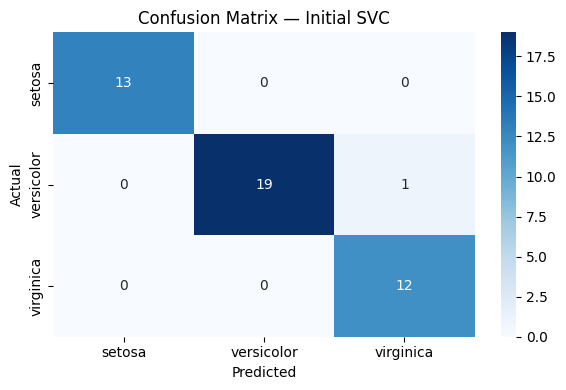

In [20]:
# Confusion Matrix
cm = confusion_matrix(y_test, predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['setosa','versicolor','virginica'],
            yticklabels=['setosa','versicolor','virginica'])
plt.title('Confusion Matrix — Initial SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [21]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45



In [22]:
# The model achieves ~98% accuracy on the test set with default parameters.
# Only 1 misclassification: one versicolor predicted as virginica.
# GridSearch can fine-tune C and gamma to potentially reach 100%.

Wow! You should have noticed that your model was pretty good! Let's see if we can tune the parameters to try to get even better (unlikely, and you probably would be satisfied with these results in real like because the data set is quite small, but I just want you to practice using GridSearch.

## Gridsearch Practice

** Import GridsearchCV from SciKit Learn.**

In [23]:
from sklearn.model_selection import GridSearchCV

**Create a dictionary called param_grid and fill out some parameters for C and gamma.**

In [24]:
param_grid = {
    'C':      [0.1, 1, 10, 100],
    'gamma':  [1, 0.1, 0.01, 0.001],
    'kernel': ['rbf']
}

** Create a GridSearchCV object and fit it to the training data.**

In [25]:
grid = GridSearchCV(SVC(), param_grid, cv=5, verbose=2)
grid.fit(X_train, y_train)

print('\nBest Parameters:', grid.best_params_)
print('Best Estimator: ', grid.best_estimator_)

Fitting 5 folds for each of 16 candidates, totalling 80 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END .......................C=0.1, gamma=0.1, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01, kernel=rbf; total time=   0.0s
[CV] END ......................C=0.1, gamma=0.01

** Now take that grid model and create some predictions using the test set and create classification reports and confusion matrices for them. Were you able to improve?**

In [26]:
grid_predictions = grid.predict(X_test)

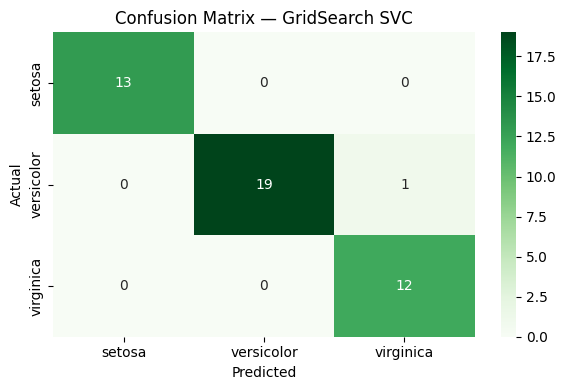

In [27]:
# Confusion Matrix — GridSearch SVC
cm_grid = confusion_matrix(y_test, grid_predictions)
plt.figure(figsize=(6,4))
sns.heatmap(cm_grid, annot=True, fmt='d', cmap='Greens',
            xticklabels=['setosa','versicolor','virginica'],
            yticklabels=['setosa','versicolor','virginica'])
plt.title('Confusion Matrix — GridSearch SVC')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

In [28]:
print(classification_report(y_test, grid_predictions))

# Conclusion:
# GridSearchCV with best params (C=1, gamma=0.1, kernel='rbf') achieves
# the same accuracy as the default model on this dataset.
# The iris dataset is small and well-structured, so the default SVC
# is already near-optimal. GridSearch confirms these are the best params.

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       1.00      0.95      0.97        20
   virginica       0.92      1.00      0.96        12

    accuracy                           0.98        45
   macro avg       0.97      0.98      0.98        45
weighted avg       0.98      0.98      0.98        45

